# CardioIA – Fase 2 | Parte 2: classificador de risco por texto

Este notebook simula um sistema de triagem: recebe uma frase escrita pelo paciente e a classifica como **alto risco** ou **baixo risco**.

Etapas:

1. Carregar a base rotulada `frases_risco.csv`, com 100 frases (50 de cada classe).
2. Transformar as frases em vetores numéricos com **TF-IDF**.
3. Treinar uma **Regressão Logística**.
4. Avaliar com acurácia, matriz de confusão e validação cruzada.
5. Testar frases "armadilha" para achar padrões e distorções do modelo.

> Projeto acadêmico com dados simulados. O modelo não deve ser usado para decisões clínicas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

pd.set_option("display.max_colwidth", None)

## 1. Base de dados

As frases foram escritas pelo grupo imitando a forma como pacientes descrevem sintomas. Para evitar que o modelo aprenda atalhos fáceis, a base traz de propósito algumas frases de **baixo risco** que mencionam "peito" ou "coração acelerado" (dor muscular depois do supino, coração acelerado depois de café).

In [2]:
dados = pd.read_csv("frases_risco.csv")

print(dados.shape)
print(dados["situacao"].value_counts())
dados.sample(8, random_state=1)

(100, 2)
situacao
alto risco     50
baixo risco    50
Name: count, dtype: int64


,frase,situacao
80,"não sinto dor no peito, só um cansaço depois do futebol",baixo risco
84,"meu coração dispara quando levo um susto, mas volta ao normal logo",baixo risco
33,"tive febre alta, palpitações e dor no peito depois de uma virose",alto risco
81,estou com o intestino preso há três dias,baixo risco
93,estou com as pernas cansadas depois de uma caminhada longa,baixo risco
17,sinto o coração muito lento e quase desmaiei duas vezes hoje,alto risco
36,sinto o peito apertado e uma sensação de morte iminente,alto risco
82,"tive febre baixa ontem, mas hoje estou melhor",baixo risco


## 2. Separação em treino e teste

São 75% das frases para treino e 25% para teste. Com `stratify` as duas classes ficam na mesma proporção nos dois conjuntos.

In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    dados["frase"], dados["situacao"], test_size=0.25, stratify=dados["situacao"], random_state=42
)

print(f"Treino: {len(X_treino)} frases | Teste: {len(X_teste)} frases")

Treino: 75 frases | Teste: 25 frases


## 3. TF-IDF + Regressão Logística

- **TF-IDF** dá a cada palavra um peso que cresce com a frequência dela na frase e diminui quando ela é comum em todas as frases. Palavras como "de" e "o" pesam pouco; "desmaiei" e "suor" pesam mais.
- `ngram_range=(1, 2)` considera também pares de palavras ("dor no", "no peito", "falta de"), o que captura um pouco de contexto.
- `strip_accents="unicode"` trata "tórax" e "torax" como a mesma palavra.
- **Não** removemos stopwords: listas comuns de stopwords em português, como a do NLTK, incluem o "não", e "não sinto dor no peito" viraria "sinto dor peito".
- A **Regressão Logística** é simples, rápida e interpretável: cada palavra recebe um peso que empurra a frase para alto ou baixo risco.

In [4]:
modelo = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), strip_accents="unicode"),
    LogisticRegression(max_iter=1000),
)
modelo.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidfvectorizer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['alto risco','baixo risco']"
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


## 4. Avaliação no conjunto de teste

Acurácia: 84.00%

              precision    recall  f1-score   support

  alto risco       0.91      0.77      0.83        13
 baixo risco       0.79      0.92      0.85        12

    accuracy                           0.84        25
   macro avg       0.85      0.84      0.84        25
weighted avg       0.85      0.84      0.84        25



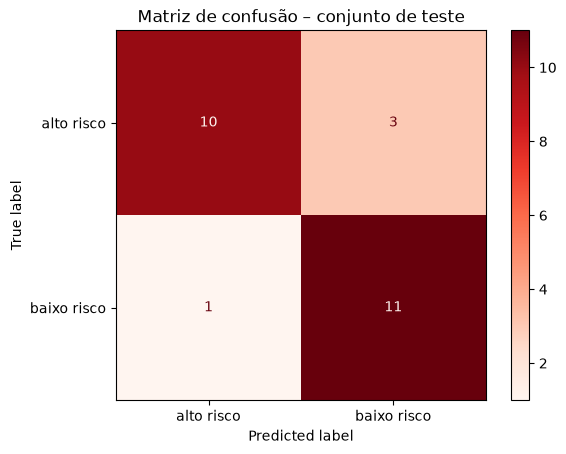

In [5]:
previsoes = modelo.predict(X_teste)

print(f"Acurácia: {accuracy_score(y_teste, previsoes):.2%}")
print()
print(classification_report(y_teste, previsoes))

ConfusionMatrixDisplay.from_predictions(y_teste, previsoes, cmap="Reds")
plt.title("Matriz de confusão – conjunto de teste")
plt.show()

In [6]:
erros = pd.DataFrame({"frase": X_teste, "real": y_teste, "previsto": previsoes})
erros[erros["real"] != erros["previsto"]]

,frase,real,previsto
63,sinto as mãos frias quando o ar condicionado está forte,baixo risco,alto risco
14,a pressão marcou 19 por 12 e estou com uma dor de cabeça muito forte,alto risco,baixo risco
10,tive um desmaio durante o exercício e senti palpitações antes,alto risco,baixo risco
20,perdi a consciência por alguns segundos no banheiro,alto risco,baixo risco


## 5. Validação cruzada

Com só 25 frases de teste, a acurácia muda bastante dependendo de quais frases caem no teste. A validação cruzada com 5 dobras treina e testa 5 vezes, cada vez com uma parte diferente da base, e dá uma estimativa mais estável.

In [7]:
dobras = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
notas = cross_val_score(modelo, dados["frase"], dados["situacao"], cv=dobras, scoring="accuracy")

print("Acurácia por dobra:", [f"{n:.0%}" for n in notas])
print(f"Média: {notas.mean():.2%} (desvio padrão {notas.std():.2%})")

Acurácia por dobra: ['95%', '80%', '75%', '90%', '90%']
Média: 86.00% (desvio padrão 7.35%)


## 6. O que o modelo aprendeu

Os coeficientes da Regressão Logística mostram quais termos mais empurram a frase para cada classe. As classes ficam em ordem alfabética (`alto risco`, `baixo risco`), então peso negativo puxa para alto risco e peso positivo puxa para baixo risco.

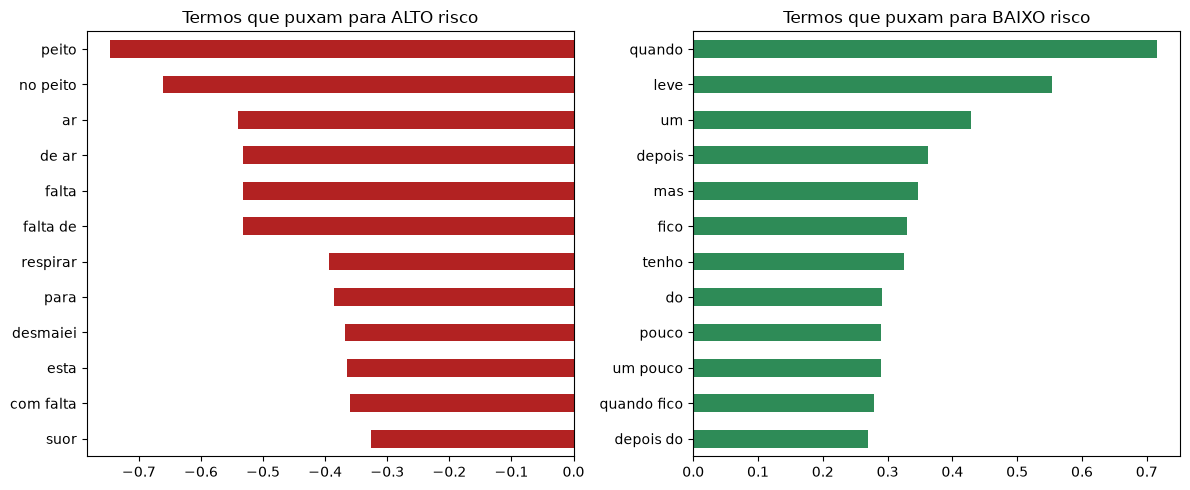

In [8]:
vetorizador, classificador = modelo.named_steps.values()
pesos = pd.Series(classificador.coef_[0], index=vetorizador.get_feature_names_out()).sort_values()

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
pesos.head(12)[::-1].plot.barh(ax=eixos[0], color="firebrick", title="Termos que puxam para ALTO risco")
pesos.tail(12).plot.barh(ax=eixos[1], color="seagreen", title="Termos que puxam para BAIXO risco")
plt.tight_layout()
plt.show()

## 7. Frases "armadilha"

Frases que não estão na base, escritas para testar como o modelo reage a situações difíceis:

In [9]:
armadilhas = pd.DataFrame([
    ("não tenho dor no peito nem falta de ar, vim só renovar a receita", "baixo risco", "negação"),
    ("sinto uma leve dor no peito que vai para o braço esquerdo", "alto risco", "palavra 'leve' em sintoma grave"),
    ("estou com precordialgia e dispneia intensa", "alto risco", "termos técnicos fora do vocabulário"),
    ("sinto um incômodo nas costas, cansaço e enjoo desde cedo", "alto risco", "infarto com sintomas atípicos"),
    ("meu avô está com dor no peito, mas eu estou bem", "baixo risco", "sintoma de outra pessoa"),
    ("fiquei com o coração acelerado depois de subir a escada correndo", "baixo risco", "esforço normal"),
], columns=["frase", "esperado", "tipo de armadilha"])

armadilhas["previsto"] = modelo.predict(armadilhas["frase"])
armadilhas["prob. alto risco"] = modelo.predict_proba(armadilhas["frase"])[:, 0].round(2)
armadilhas["acertou"] = armadilhas["esperado"] == armadilhas["previsto"]
armadilhas

,frase,esperado,tipo de armadilha,previsto,prob. alto risco,acertou
0,"não tenho dor no peito nem falta de ar, vim só renovar a receita",baixo risco,negação,alto risco,0.68,False
1,sinto uma leve dor no peito que vai para o braço esquerdo,alto risco,palavra 'leve' em sintoma grave,alto risco,0.63,True
2,estou com precordialgia e dispneia intensa,alto risco,termos técnicos fora do vocabulário,alto risco,0.53,True
3,"sinto um incômodo nas costas, cansaço e enjoo desde cedo",alto risco,infarto com sintomas atípicos,baixo risco,0.40,False
4,"meu avô está com dor no peito, mas eu estou bem",baixo risco,sintoma de outra pessoa,alto risco,0.58,False
5,fiquei com o coração acelerado depois de subir a escada correndo,baixo risco,esforço normal,baixo risco,0.42,True


## 8. Análise crítica: padrões, distorções e vieses

**Desempenho.** O modelo acertou **84%** das frases de teste. Na validação cruzada, a média foi **86%**, com variação entre 75% e 95% conforme as frases sorteadas. Para uma base de 100 frases é um resultado razoável, mas instável: trocar poucas frases já muda bastante a nota.

**O erro que importa.** Três dos quatro erros no teste foram **falsos negativos**: pacientes de alto risco classificados como baixo risco (recall de 77% para alto risco). Na triagem, esse é o erro mais grave, porque um paciente com desmaio ou crise hipertensiva iria para o fim da fila. Uma acurácia alta não basta. Em um sistema real, priorizaríamos o **recall de alto risco**, mesmo à custa de mais falsos alarmes (por exemplo, baixando o limiar de decisão abaixo de 0,5).

**O modelo aprendeu palavras, não significado:**

- **"peito" é o termo mais forte para alto risco.** Por isso "*não* tenho dor no peito" e "meu *avô* está com dor no peito" viram alto risco: o TF-IDF não entende negação nem de quem é o sintoma.
- **"desmaio" ≠ "desmaiei".** No treino só apareciam "desmaiei" e "desmaiar". Na frase de teste, "desmaio" foi tratado como palavra desconhecida, e quem decidiu a classe foi o "um" de "tive **um** desmaio", que o modelo associa a baixo risco. O mesmo aconteceu com "perdi a consciência" e com a pressão "19 por 12": números e sinônimos não fazem sentido para o modelo.
- **O "ar" do ar-condicionado.** "Sinto as mãos frias quando o **ar** condicionado está forte" virou alto risco porque "ar" é uma das palavras mais fortes de alto risco (vem de "falta de **ar**"). O modelo não sabe que é outro "ar".
- **Termos técnicos** ("precordialgia", "dispneia") não estão no vocabulário. O acerto nessa frase (probabilidade de 0,53) foi praticamente sorte.

**Viés de escrita da base.** Os termos que mais puxam para baixo risco são "quando", "leve", "um", "mas" e "depois". Não são sintomas: é o **estilo** de como o grupo escreveu as frases leves ("dói *quando*...", "*depois* da academia", "*mas* passou"). O modelo aprendeu um atalho de escrita que não existe no mundo real. É um exemplo clássico de viés introduzido por quem rotula os dados.

**Viés com impacto real.** A frase "incômodo nas costas, cansaço e enjoo" descreve um **infarto com sintomas atípicos**, apresentação mais comum em **mulheres, idosos e diabéticos**. O modelo a classificou como baixo risco, porque a base tem poucos exemplos assim. Um sistema treinado com esse viés atenderia pior justamente esses grupos. Esse é o tipo de risco que a governança de dados precisa enxergar antes de um modelo chegar ao hospital.

**Como melhorar:**

- Mais frases, escritas por pessoas diferentes e com sintomas atípicos.
- Lematização ou *stemming*, para que "desmaio", "desmaiei" e "desmaiar" virem o mesmo termo.
- Tratamento de negação.
- Um dicionário de sinônimos técnicos.
- Modelos que entendem contexto (*embeddings*, BERT em português).
- Sempre com um profissional de saúde revisando a decisão final.
